# BMI Modeling with FaceNet / VGGFace2 Features

This notebook tries to improve BMI prediction accuracy by replacing ImageNet VGG16 features with face-specific embeddings.

Main idea:

```text
image -> MTCNN face alignment -> FaceNet pretrained on VGGFace2 -> 512-d face embedding -> regression model -> BMI
```

This is closer to the paper's strongest idea because the paper's best result used **VGG-Face**, not a general ImageNet model.

## 0. Install Dependency

Run this cell once if `facenet_pytorch` is not installed. The `--no-deps` flag keeps your existing PyTorch installation unchanged.

In [1]:
# Run this only if the dependency-check cell says facenet_pytorch is missing.
%pip install facenet-pytorch --no-deps

# Optional: run this if you want to try the DeepFace VGG-Face regression section.
# This borrows the strongest idea from the comparison notebook: VGG-Face features.
%pip install deepface

Note: you may need to restart the kernel to use updated packages.


## 1. Dependency Check

In [2]:
import importlib.util

missing = []
for package in ["facenet_pytorch", "torch", "torchvision", "sklearn"]:
    if importlib.util.find_spec(package) is None:
        missing.append(package)

if missing:
    raise ImportError(f"Missing packages: {missing}. Install facenet_pytorch first, then restart the kernel.")

print("All required packages are available.")

All required packages are available.


## 2. Imports

In [3]:
from pathlib import Path
import json
import math
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from facenet_pytorch import MTCNN, InceptionResnetV1

from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 3. Configuration

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu")

# facenet_pytorch MTCNN can fail on Apple MPS for some image sizes because of adaptive pooling.
# Keep face detection/alignment on CPU; embedding can still use DEVICE.
MTCNN_DEVICE = torch.device("cpu")

print("Embedding device:", DEVICE)
print("MTCNN device:", MTCNN_DEVICE)

Embedding device: mps
MTCNN device: cpu


In [5]:
QUICK_RUN = False
QUICK_TRAIN_N = 300
QUICK_TEST_N = 120

BATCH_SIZE = 32
PCA_COMPONENTS = 128
CV_FOLDS = 3

USE_GENDER_FEATURE = True
USE_CLIPPED_TARGET = False
CLIP_LOWER_Q = 0.01
CLIP_UPPER_Q = 0.99

RUN_ADVANCED_SEARCH = True

# DeepFace/TensorFlow can crash in some local Python 3.13 environments.
# Keep this False locally unless the safety check below passes, or run it in Colab.
RUN_DEEPFACE_VGGFACE = False
VGGFACE_PCA_COMPONENTS = 256

# Set True only after the notebook runs successfully once.
TRY_XGBOOST = False

## 4. Paths

In [6]:
PROJECT_DIR = Path.cwd()
ROOT_DIR = PROJECT_DIR.parent if PROJECT_DIR.name.lower() == "final project" else PROJECT_DIR

FINAL_DIR = ROOT_DIR / "Final project"
OUTPUT_DIR = FINAL_DIR / "outputs"
FEATURE_DIR = OUTPUT_DIR / "features"
MODEL_DIR = OUTPUT_DIR / "models"

for directory in [OUTPUT_DIR, FEATURE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = OUTPUT_DIR / "bmi_clean_manifest.csv"
print("Manifest:", MANIFEST_PATH)

Manifest: /Users/jiayingzhong/Desktop/ML_2/Final project/outputs/bmi_clean_manifest.csv


## 5. Load Manifest

In [7]:
df = pd.read_csv(MANIFEST_PATH)
df["image_path"] = df["image_path"].astype(str)
df["gender_code"] = df["gender"].map({"Female": 0, "Male": 1}).astype(float)

train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
test_df = df[df["split"] == "test"].copy().reset_index(drop=True)

if QUICK_RUN:
    train_df = train_df.sample(min(QUICK_TRAIN_N, len(train_df)), random_state=SEED).reset_index(drop=True)
    test_df = test_df.sample(min(QUICK_TEST_N, len(test_df)), random_state=SEED).reset_index(drop=True)

print("QUICK_RUN:", QUICK_RUN)
print("Train:", train_df.shape)
print("Test:", test_df.shape)
display(train_df.head())

QUICK_RUN: False
Train: (3210, 14)
Test: (752, 14)


,row_id,name,image_path,bmi,bmi_category,gender,is_training,split,width,height,mode,aspect_ratio,pixels,gender_code
0,0,img_0.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,34.207396,obese,Male,1,train,164,176,RGB,0.931818,28864,1.0
1,1,img_1.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,26.453720,overweight,Male,1,train,150,173,RGB,0.867052,25950,1.0
2,2,img_2.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,34.967561,obese,Female,1,train,226,251,RGB,0.900398,56726,0.0
3,3,img_3.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,22.044766,normal,Female,1,train,97,126,RGB,0.769841,12222,0.0
4,6,img_6.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,25.845588,overweight,Female,1,train,87,115,RGB,0.756522,10005,0.0


## 6. Evaluation Helpers

In [8]:
def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 2 or np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])

def regression_report(y_true, y_pred):
    return {
        "Pearson_r": pearson_r(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

In [9]:
def evaluate_by_gender(frame, pred_col="pred"):
    rows = []
    rows.append({"group": "Overall", "n": len(frame), **regression_report(frame["bmi"], frame[pred_col])})
    for gender, group in frame.groupby("gender"):
        rows.append({"group": gender, "n": len(group), **regression_report(group["bmi"], group[pred_col])})
    return pd.DataFrame(rows).set_index("group").round(4)

def pearson_scorer_func(y_true, y_pred):
    value = pearson_r(y_true, y_pred)
    return -1.0 if np.isnan(value) else value

pearson_scorer = make_scorer(pearson_scorer_func, greater_is_better=True)

## 7. Initialize MTCNN and FaceNet

The first run may download the VGGFace2 pretrained FaceNet weights.

In [10]:
mtcnn = MTCNN(
    image_size=160,
    margin=20,
    keep_all=False,
    post_process=True,
    device=MTCNN_DEVICE,
)

facenet = InceptionResnetV1(pretrained="vggface2").eval().to(DEVICE)
print("MTCNN and FaceNet are ready.")

MTCNN and FaceNet are ready.


## 8. Quick Face Alignment Preview

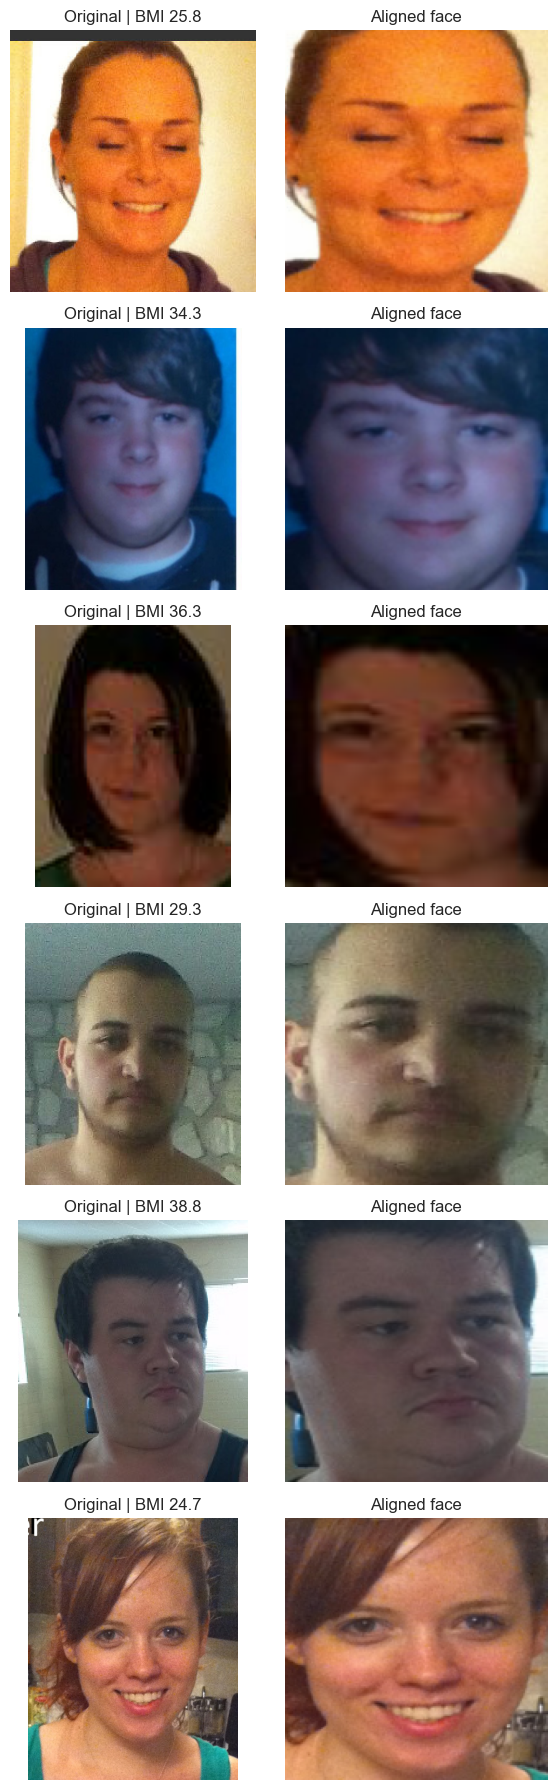

In [11]:
sample = train_df.sample(min(6, len(train_df)), random_state=SEED)

fig, axes = plt.subplots(len(sample), 2, figsize=(6, 3 * len(sample)))
axes = np.array(axes).reshape(-1, 2)

for row_idx, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    face = mtcnn(img)

    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].set_title(f"Original | BMI {row['bmi']:.1f}")
    axes[row_idx, 0].axis("off")

    if face is None:
        axes[row_idx, 1].text(0.5, 0.5, "No face detected", ha="center", va="center")
    else:
        face_img = face.permute(1, 2, 0).cpu().numpy()
        face_img = np.clip((face_img + 1) / 2, 0, 1)
        axes[row_idx, 1].imshow(face_img)
    axes[row_idx, 1].set_title("Aligned face")
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()

## 9. Extract FaceNet Embeddings

In [12]:
@torch.no_grad()
def embed_face_batch(face_tensors):
    batch = torch.stack(face_tensors).to(DEVICE)
    embeddings = facenet(batch).cpu().numpy()
    return embeddings

In [13]:
def extract_embeddings(frame, batch_size=BATCH_SIZE):
    rows, faces, embeddings = [], [], []
    failed = []
    start = time.time()

    for idx, row in frame.iterrows():
        img = Image.open(row["image_path"]).convert("RGB")
        face = mtcnn(img)

        if face is None:
            failed.append(row["name"])
            continue

        faces.append(face)
        rows.append(row)

        if len(faces) == batch_size:
            embeddings.append(embed_face_batch(faces))
            faces = []

    if faces:
        embeddings.append(embed_face_batch(faces))

    used_df = pd.DataFrame(rows).reset_index(drop=True)
    X = np.vstack(embeddings) if embeddings else np.empty((0, 512))
    print(f"Embedded {len(used_df)} / {len(frame)} images in {time.time() - start:.1f}s")
    print("Face detection failures:", len(failed))
    return X, used_df, failed

## 10. Load Cached Embeddings or Compute Them

In [14]:
suffix = "quick" if QUICK_RUN else "full"
train_embed_path = FEATURE_DIR / f"facenet_vggface2_train_{suffix}.npz"
test_embed_path = FEATURE_DIR / f"facenet_vggface2_test_{suffix}.npz"

def save_embedding_cache(path, X, frame, failed):
    np.savez_compressed(
        path,
        X=X,
        names=frame["name"].to_numpy(),
        bmi=frame["bmi"].to_numpy(),
        gender=frame["gender"].to_numpy(),
        gender_code=frame["gender_code"].to_numpy(),
        failed=np.array(failed, dtype=object),
    )

def load_embedding_cache(path):
    data = np.load(path, allow_pickle=True)
    frame = pd.DataFrame({
        "name": data["names"],
        "bmi": data["bmi"],
        "gender": data["gender"],
        "gender_code": data["gender_code"],
    })
    image_path_lookup = df.set_index("name")["image_path"].to_dict()
    frame["image_path"] = frame["name"].map(image_path_lookup)
    return data["X"], frame, list(data["failed"])

In [15]:
if train_embed_path.exists() and test_embed_path.exists():
    X_train, train_used_df, train_failed = load_embedding_cache(train_embed_path)
    X_test, test_used_df, test_failed = load_embedding_cache(test_embed_path)
    print("Loaded cached FaceNet embeddings.")
else:
    X_train, train_used_df, train_failed = extract_embeddings(train_df)
    X_test, test_used_df, test_failed = extract_embeddings(test_df)
    save_embedding_cache(train_embed_path, X_train, train_used_df, train_failed)
    save_embedding_cache(test_embed_path, X_test, test_used_df, test_failed)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Loaded cached FaceNet embeddings.
X_train: (3204, 512)
X_test: (750, 512)


## 11. Prepare Features and Target

In [16]:
y_train_raw = train_used_df["bmi"].to_numpy(dtype=float)
y_test = test_used_df["bmi"].to_numpy(dtype=float)

if USE_CLIPPED_TARGET:
    lower = np.quantile(y_train_raw, CLIP_LOWER_Q)
    upper = np.quantile(y_train_raw, CLIP_UPPER_Q)
    y_train = np.clip(y_train_raw, lower, upper)
    print("Training target clipped to:", round(lower, 2), round(upper, 2))
else:
    y_train = y_train_raw.copy()

gender_train = train_used_df["gender_code"].to_numpy(dtype=float).reshape(-1, 1)
gender_test = test_used_df["gender_code"].to_numpy(dtype=float).reshape(-1, 1)

In [17]:
n_components = min(PCA_COMPONENTS, X_train.shape[0] - 1, X_train.shape[1])
pca = make_pipeline(StandardScaler(), PCA(n_components=n_components, random_state=SEED))

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

if USE_GENDER_FEATURE:
    X_train_model = np.hstack([X_train_pca, gender_train])
    X_test_model = np.hstack([X_test_pca, gender_test])
else:
    X_train_model = X_train_pca
    X_test_model = X_test_pca

print("PCA components:", n_components)
print("Train model shape:", X_train_model.shape)

PCA components: 128
Train model shape: (3204, 129)


## 12. Baseline on FaceNet Embeddings: Ridge

In [18]:
ridge = RidgeCV(alphas=np.logspace(-2, 4, 20))
ridge.fit(X_train_model, y_train)
pred_ridge = ridge.predict(X_test_model)

ridge_result = test_used_df.copy()
ridge_result["pred"] = pred_ridge

print("Best Ridge alpha:", ridge.alpha_)
display(evaluate_by_gender(ridge_result))

Best Ridge alpha: 0.01


,n,Pearson_r,MAE,RMSE,R2
group,,,,,
Overall,750,0.6532,5.0930,7.0368,0.4177
Female,323,0.6404,5.2703,7.3831,0.3974
Male,427,0.6714,4.9589,6.7631,0.4319


## 13. Tuned SVR on FaceNet Embeddings

In [19]:
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

svr_grid = {
    "svr__C": [1.0, 3.0, 10.0, 30.0],
    "svr__epsilon": [0.1, 0.5, 1.0],
    "svr__gamma": ["scale", 0.001, 0.003],
}

svr_search = GridSearchCV(
    make_pipeline(StandardScaler(), SVR(kernel="rbf")),
    param_grid=svr_grid,
    scoring=pearson_scorer,
    cv=cv,
    n_jobs=1,
    verbose=1,
)

svr_search.fit(X_train_model, y_train)
pred_svr = svr_search.predict(X_test_model)

svr_result = test_used_df.copy()
svr_result["pred"] = pred_svr

print("Best SVR params:", svr_search.best_params_)
print("Best CV Pearson r:", round(svr_search.best_score_, 4))
display(evaluate_by_gender(svr_result))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best SVR params: {'svr__C': 30.0, 'svr__epsilon': 0.1, 'svr__gamma': 'scale'}
Best CV Pearson r: 0.7135


,n,Pearson_r,MAE,RMSE,R2
group,,,,,
Overall,750,0.6292,5.2240,7.2376,0.3840
Female,323,0.6203,5.2723,7.4977,0.3786
Male,427,0.6421,5.1874,7.0344,0.3854


## 14. Optional XGBoost

In [20]:
xgb_result = None
pred_xgb = None

if TRY_XGBOOST:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=1,
    )
    xgb.fit(X_train_model, y_train)
    pred_xgb = xgb.predict(X_test_model)
    xgb_result = test_used_df.copy()
    xgb_result["pred"] = pred_xgb
    display(evaluate_by_gender(xgb_result))
else:
    print("Skipping XGBoost. Set TRY_XGBOOST=True to run it.")

Skipping XGBoost. Set TRY_XGBOOST=True to run it.


## 15. Advanced Variant: Raw FaceNet Embeddings

PCA can remove noise, but it can also discard useful face information. This section tries the original 512-d FaceNet embedding directly.

In [21]:
advanced_predictions = {}
advanced_models = {}

if USE_GENDER_FEATURE:
    X_train_raw_model = np.hstack([X_train, gender_train])
    X_test_raw_model = np.hstack([X_test, gender_test])
else:
    X_train_raw_model = X_train
    X_test_raw_model = X_test

print("Raw model feature shape:", X_train_raw_model.shape)

Raw model feature shape: (3204, 513)


In [22]:
raw_ridge = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-2, 5, 25)),
)
raw_ridge.fit(X_train_raw_model, y_train)
pred_raw_ridge = raw_ridge.predict(X_test_raw_model)

raw_ridge_result = test_used_df.copy()
raw_ridge_result["pred"] = pred_raw_ridge

advanced_predictions["Raw FaceNet + Ridge"] = pred_raw_ridge
advanced_models["Raw FaceNet + Ridge"] = raw_ridge
display(evaluate_by_gender(raw_ridge_result))

,n,Pearson_r,MAE,RMSE,R2
group,,,,,
Overall,750,0.6595,5.0466,6.9880,0.4257
Female,323,0.6523,5.2200,7.3065,0.4099
Male,427,0.6743,4.9154,6.7371,0.4362


## 16. Advanced Variant: Target-Standardized SVR

SVR is sensitive to target scale because `epsilon` is measured in target units. Standardizing BMI during training can make SVR tuning more stable.

In [23]:
if RUN_ADVANCED_SEARCH:
    target_svr_grid = {
        "regressor__svr__C": [3.0, 10.0, 30.0, 100.0],
        "regressor__svr__epsilon": [0.03, 0.06, 0.10, 0.20],
        "regressor__svr__gamma": ["scale", 0.001, 0.003],
    }

    target_svr = TransformedTargetRegressor(
        regressor=make_pipeline(StandardScaler(), SVR(kernel="rbf")),
        transformer=StandardScaler(),
    )

    target_svr_search = GridSearchCV(
        target_svr,
        param_grid=target_svr_grid,
        scoring=pearson_scorer,
        cv=cv,
        n_jobs=1,
        verbose=1,
    )
    target_svr_search.fit(X_train_raw_model, y_train)
    pred_target_svr = target_svr_search.predict(X_test_raw_model)

    target_svr_result = test_used_df.copy()
    target_svr_result["pred"] = pred_target_svr

    advanced_predictions["Raw FaceNet + target-scaled SVR"] = pred_target_svr
    advanced_models["Raw FaceNet + target-scaled SVR"] = target_svr_search.best_estimator_

    print("Best target-scaled SVR params:", target_svr_search.best_params_)
    print("Best CV Pearson r:", round(target_svr_search.best_score_, 4))
    display(evaluate_by_gender(target_svr_result))
else:
    print("Skipping target-standardized SVR. Set RUN_ADVANCED_SEARCH=True to run it.")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best target-scaled SVR params: {'regressor__svr__C': 3.0, 'regressor__svr__epsilon': 0.1, 'regressor__svr__gamma': 0.003}
Best CV Pearson r: 0.6913


,n,Pearson_r,MAE,RMSE,R2
group,,,,,
Overall,750,0.6150,5.2762,7.3318,0.3678
Female,323,0.6093,5.1902,7.5488,0.3701
Male,427,0.6246,5.3412,7.1633,0.3627


## 17. Advanced Variant: Gender-Specific FaceNet Models

This trains one model for male samples and one for female samples. It may help if the face-to-BMI relationship differs by gender, but it can also overfit because each model gets fewer samples.

In [24]:
def fit_gender_specific_ridge(X_train_base, y_train_base, train_frame, X_test_base, test_frame):
    preds = np.zeros(len(test_frame), dtype=float)
    models = {}
    fallback = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 5, 25)))
    fallback.fit(X_train_base, y_train_base)

    for gender in sorted(train_frame["gender"].unique()):
        train_mask = train_frame["gender"].to_numpy() == gender
        test_mask = test_frame["gender"].to_numpy() == gender
        if train_mask.sum() < 50 or test_mask.sum() == 0:
            preds[test_mask] = fallback.predict(X_test_base[test_mask])
            continue
        model = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 5, 25)))
        model.fit(X_train_base[train_mask], y_train_base[train_mask])
        preds[test_mask] = model.predict(X_test_base[test_mask])
        models[gender] = model
    return preds, models

In [25]:
pred_gender_ridge, gender_ridge_models = fit_gender_specific_ridge(
    X_train, y_train, train_used_df, X_test, test_used_df
)

gender_ridge_result = test_used_df.copy()
gender_ridge_result["pred"] = pred_gender_ridge

advanced_predictions["Gender-specific Raw FaceNet + Ridge"] = pred_gender_ridge
advanced_models["Gender-specific Raw FaceNet + Ridge"] = gender_ridge_models
display(evaluate_by_gender(gender_ridge_result))

,n,Pearson_r,MAE,RMSE,R2
group,,,,,
Overall,750,0.6339,5.1731,7.1648,0.3963
Female,323,0.6061,5.3600,7.5731,0.3660
Male,427,0.6650,5.0317,6.8397,0.4189


## 18. Borrowed Variant: DeepFace VGG-Face Regression

The comparison notebook's strongest useful idea is using a VGG-Face backbone. Here we use DeepFace VGG-Face as a feature extractor, but keep our task as BMI regression instead of BMI category classification.

In [26]:
import subprocess
import sys

DEEPFACE_AVAILABLE = False
RUN_VGGFACE_SECTION = False

if RUN_DEEPFACE_VGGFACE:
    # Safety check: DeepFace/TensorFlow may hard-crash the kernel in some local environments.
    check = subprocess.run(
        [sys.executable, "-c", "from deepface import DeepFace; print('ok')"],
        capture_output=True,
        text=True,
    )
    if check.returncode == 0:
        from deepface import DeepFace
        DEEPFACE_AVAILABLE = True
        RUN_VGGFACE_SECTION = True
    else:
        print("DeepFace import failed or crashed in a subprocess, so this section is skipped locally.")
        print("Return code:", check.returncode)
        print("stderr preview:", check.stderr[:500])
        print("Recommendation: run the DeepFace VGG-Face variant in Colab or a Python 3.10/3.11 TensorFlow environment.")
else:
    print("DeepFace VGG-Face section is disabled. Set RUN_DEEPFACE_VGGFACE=True only in a compatible environment.")

print("Run DeepFace VGG-Face section:", RUN_VGGFACE_SECTION)

DeepFace VGG-Face section is disabled. Set RUN_DEEPFACE_VGGFACE=True only in a compatible environment.
Run DeepFace VGG-Face section: False


In [27]:
def extract_deepface_vggface_embeddings(frame):
    embeddings = []
    rows = []
    failed = []
    start = time.time()

    for idx, row in frame.iterrows():
        try:
            reps = DeepFace.represent(
                img_path=row["image_path"],
                model_name="VGG-Face",
                detector_backend="skip",
                enforce_detection=False,
                align=False,
            )
            embeddings.append(np.asarray(reps[0]["embedding"], dtype=np.float32))
            rows.append(row)
        except Exception as exc:
            failed.append((row["name"], repr(exc)))

        if (idx + 1) % 250 == 0:
            print(f"Processed {idx + 1} rows in {time.time() - start:.1f}s")

    used = pd.DataFrame(rows).reset_index(drop=True)
    X = np.vstack(embeddings) if embeddings else np.empty((0, 0))
    print(f"VGG-Face embedded {len(used)} / {len(frame)} images. Failures: {len(failed)}")
    return X, used, failed

In [28]:
vggface_train_path = FEATURE_DIR / f"deepface_vggface_train_{suffix}.npz"
vggface_test_path = FEATURE_DIR / f"deepface_vggface_test_{suffix}.npz"

def save_vggface_cache(path, X, frame, failed):
    np.savez_compressed(
        path,
        X=X,
        names=frame["name"].to_numpy(),
        bmi=frame["bmi"].to_numpy(),
        gender=frame["gender"].to_numpy(),
        gender_code=frame["gender_code"].to_numpy(),
        failed=np.array(failed, dtype=object),
    )

def load_vggface_cache(path):
    data = np.load(path, allow_pickle=True)
    frame = pd.DataFrame({
        "name": data["names"],
        "bmi": data["bmi"],
        "gender": data["gender"],
        "gender_code": data["gender_code"],
    })
    return data["X"], frame, list(data["failed"])

In [29]:
if RUN_VGGFACE_SECTION:
    if vggface_train_path.exists() and vggface_test_path.exists():
        X_vgg_train, vgg_train_df, vgg_train_failed = load_vggface_cache(vggface_train_path)
        X_vgg_test, vgg_test_df, vgg_test_failed = load_vggface_cache(vggface_test_path)
        print("Loaded cached DeepFace VGG-Face embeddings.")
    else:
        X_vgg_train, vgg_train_df, vgg_train_failed = extract_deepface_vggface_embeddings(train_used_df)
        X_vgg_test, vgg_test_df, vgg_test_failed = extract_deepface_vggface_embeddings(test_used_df)
        save_vggface_cache(vggface_train_path, X_vgg_train, vgg_train_df, vgg_train_failed)
        save_vggface_cache(vggface_test_path, X_vgg_test, vgg_test_df, vgg_test_failed)

    print("X_vgg_train:", X_vgg_train.shape)
    print("X_vgg_test:", X_vgg_test.shape)
else:
    X_vgg_train = X_vgg_test = None
    vgg_train_df = vgg_test_df = None
    vgg_train_failed = vgg_test_failed = []

In [30]:
if RUN_VGGFACE_SECTION and X_vgg_train is not None and len(X_vgg_train) > 0:
    y_vgg_train = vgg_train_df["bmi"].to_numpy(dtype=float)
    y_vgg_test = vgg_test_df["bmi"].to_numpy(dtype=float)
    vgg_gender_train = vgg_train_df["gender_code"].to_numpy(dtype=float).reshape(-1, 1)
    vgg_gender_test = vgg_test_df["gender_code"].to_numpy(dtype=float).reshape(-1, 1)

    n_vgg_components = min(VGGFACE_PCA_COMPONENTS, X_vgg_train.shape[0] - 1, X_vgg_train.shape[1])
    vggface_pca = make_pipeline(StandardScaler(), PCA(n_components=n_vgg_components, random_state=SEED))
    X_vgg_train_pca = vggface_pca.fit_transform(X_vgg_train)
    X_vgg_test_pca = vggface_pca.transform(X_vgg_test)

    if USE_GENDER_FEATURE:
        X_vgg_train_model = np.hstack([X_vgg_train_pca, vgg_gender_train])
        X_vgg_test_model = np.hstack([X_vgg_test_pca, vgg_gender_test])
    else:
        X_vgg_train_model = X_vgg_train_pca
        X_vgg_test_model = X_vgg_test_pca

    print("VGG-Face PCA components:", n_vgg_components)
    print("VGG-Face model features:", X_vgg_train_model.shape)
else:
    vggface_pca = None

In [31]:
if RUN_VGGFACE_SECTION and vggface_pca is not None:
    vggface_ridge = RidgeCV(alphas=np.logspace(-2, 5, 25))
    vggface_ridge.fit(X_vgg_train_model, y_vgg_train)
    pred_vggface_ridge = vggface_ridge.predict(X_vgg_test_model)

    vggface_ridge_result = vgg_test_df.copy()
    vggface_ridge_result["pred"] = pred_vggface_ridge

    if len(pred_vggface_ridge) == len(y_test):
        advanced_predictions["DeepFace VGG-Face + PCA + Ridge"] = pred_vggface_ridge
        advanced_models["DeepFace VGG-Face + PCA + Ridge"] = vggface_ridge
    else:
        print("Skipping VGG-Face Ridge in final comparison because some test rows failed embedding.")
    print("DeepFace VGG-Face Ridge result:")
    display(evaluate_by_gender(vggface_ridge_result))

In [32]:
if RUN_VGGFACE_SECTION and vggface_pca is not None and RUN_ADVANCED_SEARCH:
    vggface_svr_grid = {
        "svr__C": [3.0, 10.0, 30.0],
        "svr__epsilon": [0.1, 0.5, 1.0],
        "svr__gamma": ["scale", 0.001, 0.003],
    }
    vggface_svr_search = GridSearchCV(
        make_pipeline(StandardScaler(), SVR(kernel="rbf")),
        param_grid=vggface_svr_grid,
        scoring=pearson_scorer,
        cv=cv,
        n_jobs=1,
        verbose=1,
    )
    vggface_svr_search.fit(X_vgg_train_model, y_vgg_train)
    pred_vggface_svr = vggface_svr_search.predict(X_vgg_test_model)

    vggface_svr_result = vgg_test_df.copy()
    vggface_svr_result["pred"] = pred_vggface_svr

    if len(pred_vggface_svr) == len(y_test):
        advanced_predictions["DeepFace VGG-Face + PCA + tuned SVR"] = pred_vggface_svr
        advanced_models["DeepFace VGG-Face + PCA + tuned SVR"] = vggface_svr_search.best_estimator_
    else:
        print("Skipping VGG-Face SVR in final comparison because some test rows failed embedding.")
    print("Best VGG-Face SVR params:", vggface_svr_search.best_params_)
    display(evaluate_by_gender(vggface_svr_result))

## 19. Advanced Variant: Selective Ensemble

Average only the strongest models. This can reduce unstable errors, but if one model is clearly best, the single model may still win.

In [33]:
base_predictions_for_ensemble = {
    "FaceNet PCA + Ridge": pred_ridge,
    "FaceNet PCA + tuned SVR": pred_svr,
    **advanced_predictions,
}

candidate_scores = []
for name, pred in base_predictions_for_ensemble.items():
    candidate_scores.append({"model": name, **regression_report(y_test, pred)})

candidate_score_table = pd.DataFrame(candidate_scores).sort_values("Pearson_r", ascending=False)
display(candidate_score_table.round(4))

top_names = candidate_score_table.head(3)["model"].tolist()
pred_selective_ensemble = np.mean([base_predictions_for_ensemble[name] for name in top_names], axis=0)

selective_ensemble_result = test_used_df.copy()
selective_ensemble_result["pred"] = pred_selective_ensemble

advanced_predictions["Top-3 selective ensemble"] = pred_selective_ensemble
print("Models in selective ensemble:", top_names)
display(evaluate_by_gender(selective_ensemble_result))

,model,Pearson_r,MAE,RMSE,R2
2,Raw FaceNet + Ridge,0.6595,5.0466,6.9880,0.4257
0,FaceNet PCA + Ridge,0.6532,5.0930,7.0368,0.4177
4,Gender-specific Raw FaceNet + Ridge,0.6339,5.1731,7.1648,0.3963
1,FaceNet PCA + tuned SVR,0.6292,5.2240,7.2376,0.3840
3,Raw FaceNet + target-scaled SVR,0.6150,5.2762,7.3318,0.3678


Models in selective ensemble: ['Raw FaceNet + Ridge', 'FaceNet PCA + Ridge', 'Gender-specific Raw FaceNet + Ridge']


,n,Pearson_r,MAE,RMSE,R2
group,,,,,
Overall,750,0.6534,5.0729,7.0328,0.4183
Female,323,0.6369,5.2504,7.3896,0.3964
Male,427,0.6743,4.9387,6.7504,0.4340


## 19. Compare Models

In [34]:
predictions = {
    "FaceNet PCA + Ridge": pred_ridge,
    "FaceNet PCA + tuned SVR": pred_svr,
}

if pred_xgb is not None:
    predictions["FaceNet PCA + XGBoost"] = pred_xgb

if "advanced_predictions" in globals():
    predictions.update(advanced_predictions)

if len(predictions) >= 2:
    predictions["FaceNet ensemble"] = np.mean(list(predictions.values()), axis=0)

rows = []
for name, pred in predictions.items():
    rows.append({"model": name, **regression_report(y_test, pred)})

comparison = pd.DataFrame(rows).sort_values("Pearson_r", ascending=False).reset_index(drop=True)
display(comparison.round(4))

,model,Pearson_r,MAE,RMSE,R2
0,Raw FaceNet + Ridge,0.6595,5.0466,6.9880,0.4257
1,FaceNet ensemble,0.6578,5.0500,7.0179,0.4208
2,Top-3 selective ensemble,0.6534,5.0729,7.0328,0.4183
3,FaceNet PCA + Ridge,0.6532,5.0930,7.0368,0.4177
4,Gender-specific Raw FaceNet + Ridge,0.6339,5.1731,7.1648,0.3963
5,FaceNet PCA + tuned SVR,0.6292,5.2240,7.2376,0.3840
6,Raw FaceNet + target-scaled SVR,0.6150,5.2762,7.3318,0.3678


In [35]:
best_model_name = comparison.iloc[0]["model"]
best_pred = predictions[best_model_name]

best_result = test_used_df.copy()
best_result["pred"] = best_pred

print("Best model:", best_model_name)
display(evaluate_by_gender(best_result))

Best model: Raw FaceNet + Ridge


,n,Pearson_r,MAE,RMSE,R2
group,,,,,
Overall,750,0.6595,5.0466,6.9880,0.4257
Female,323,0.6523,5.2200,7.3065,0.4099
Male,427,0.6743,4.9154,6.7371,0.4362


## 16. Plot Predictions

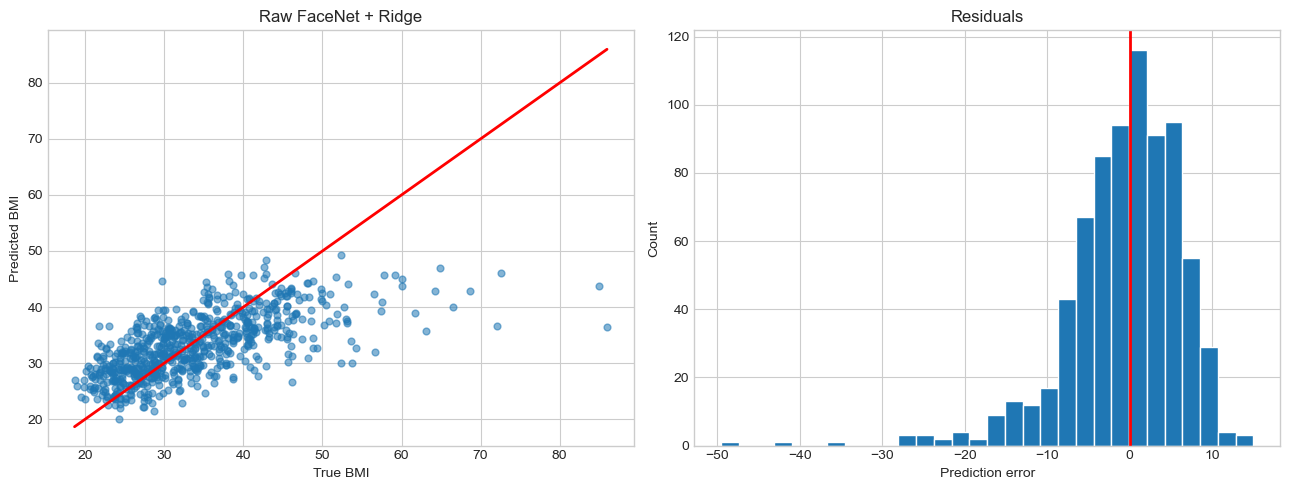

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(best_result["bmi"], best_result["pred"], alpha=0.55, s=24)
low = min(best_result["bmi"].min(), best_result["pred"].min())
high = max(best_result["bmi"].max(), best_result["pred"].max())
axes[0].plot([low, high], [low, high], color="red", linewidth=2)
axes[0].set_xlabel("True BMI")
axes[0].set_ylabel("Predicted BMI")
axes[0].set_title(best_model_name)

errors = best_result["pred"] - best_result["bmi"]
axes[1].hist(errors, bins=30, edgecolor="white")
axes[1].axvline(0, color="red", linewidth=2)
axes[1].set_xlabel("Prediction error")
axes[1].set_ylabel("Count")
axes[1].set_title("Residuals")

plt.tight_layout()
plt.show()

## 17. Save Artifacts

In [37]:
import joblib

artifact_suffix = "quick" if QUICK_RUN else "full"

joblib.dump(pca, MODEL_DIR / f"facenet_pca_{artifact_suffix}.joblib")
joblib.dump(ridge, MODEL_DIR / f"facenet_ridge_{artifact_suffix}.joblib")
joblib.dump(svr_search.best_estimator_, MODEL_DIR / f"facenet_tuned_svr_{artifact_suffix}.joblib")
if "vggface_pca" in globals() and vggface_pca is not None:
    joblib.dump(vggface_pca, MODEL_DIR / f"deepface_vggface_pca_{artifact_suffix}.joblib")

if "advanced_models" in globals():
    for model_name, model_obj in advanced_models.items():
        if isinstance(model_obj, dict):
            continue
        safe_name = model_name.lower().replace(" ", "_").replace("+", "plus").replace("-", "_")
        joblib.dump(model_obj, MODEL_DIR / f"{safe_name}_{artifact_suffix}.joblib")

comparison.to_csv(OUTPUT_DIR / f"facenet_model_comparison_{artifact_suffix}.csv", index=False)
best_result.to_csv(OUTPUT_DIR / f"facenet_best_predictions_{artifact_suffix}.csv", index=False)

summary = {
    "quick_run": QUICK_RUN,
    "best_model": best_model_name,
    "use_gender_feature": USE_GENDER_FEATURE,
    "use_clipped_target": USE_CLIPPED_TARGET,
    "comparison": comparison.to_dict(orient="records"),
    "train_detection_failures": len(train_failed),
    "test_detection_failures": len(test_failed),
}

with open(OUTPUT_DIR / f"facenet_results_{artifact_suffix}.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved FaceNet artifacts to:", OUTPUT_DIR)

Saved FaceNet artifacts to: /Users/jiayingzhong/Desktop/ML_2/Final project/outputs


Based on the updated full-data notebook, my final model uses a face-specific feature extraction pipeline rather than a general image CNN. First, MTCNN is used to detect and align faces from the input images, producing standardized face crops. Then, a FaceNet/InceptionResnetV1 model pretrained on the VGGFace2 face dataset extracts a 512-dimensional facial embedding from each aligned face. In the best-performing version, I do not apply PCA; instead, I use the raw 512-dimensional FaceNet embedding together with gender as an auxiliary feature, and train a Ridge Regression model to predict the continuous BMI value. This approach treats the CNN as a pretrained facial feature extractor, while the final BMI prediction is handled by a regression model. I also tested PCA-based Ridge, tuned SVR, target-scaled SVR, gender-specific models, and ensemble models, but the best full-test result came from Raw FaceNet + Ridge, achieving an overall Pearson correlation of 0.6595, MAE of 5.0466, RMSE of 6.9880, and R2 of 0.4257. This slightly improves over the paper’s reported VGG-Face Pearson correlation of 0.65.